In [133]:
# Importing the neccesary libraries
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
# Loading the dataset
df_raw = pd.read_csv('owid-co2-data.csv')
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

Data cleaning

In [135]:
# Dropping row that don't have iso code
df_countries = df_raw[
    df_raw["iso_code"].notna()
]

In [136]:
# Defining the target as co2
target = 'co2'

correlations = df_countries.select_dtypes(include='number').corr()[target]
print(correlations.sort_values(ascending=False))

co2                                          1.000000
total_ghg_excluding_lucf                     0.998848
consumption_co2                              0.993112
primary_energy_consumption                   0.988604
total_ghg                                    0.953452
co2_including_luc                            0.951048
share_global_other_co2                       0.950661
gdp                                          0.924912
coal_co2                                     0.923477
cumulative_coal_co2                          0.893168
other_industry_co2                           0.889258
share_global_cumulative_other_co2            0.884977
temperature_change_from_ghg                  0.882681
nitrous_oxide                                0.880835
oil_co2                                      0.874346
temperature_change_from_ch4                  0.868975
cumulative_cement_co2                        0.866290
cumulative_co2_including_luc                 0.864406
temperature_change_from_n2o 

In [137]:
# List of the columns to keep
columns_to_keep = ['country', 'year', 'iso_code', 'gdp', 'population', 'co2', 'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2', 'gas_co2', 'land_use_change_co2', 'total_ghg', 'other_industry_co2','primary_energy_consumption', 'energy_per_capita','co2_including_luc']

# Keeping relevant columns
df1 = df_countries[columns_to_keep]

In [138]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df1.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    74.509804
1751    80.693816
1752    80.693816
1753    80.693816
1754    80.693816
1755    80.693816
1756    80.693816
1757    80.693816
1758    80.693816
1759    80.693816
1760    74.509804
1761    80.693816
1762    80.693816
1763    80.693816
1764    80.693816
1765    80.693816
1766    80.693816
1767    80.693816
1768    80.693816
1769    80.693816
1770    74.509804
1771    80.693816
1772    80.693816
1773    80.693816
1774    80.693816
1775    80.693816
1776    80.693816
1777    80.693816
1778    80.693816
1779    80.693816
1780    74.509804
1781    80.693816
1782    80.693816
1783    80.693816
1784    80.693816
1785    80.294118
1786    80.294118
1787    80.294118
1788    80.294118
1789    80.294118
1790    73.970588
1791    80.294118
1792    79.913917
1793    79.913917
1794    79.913917
1795    79.913917
1796    79.913917
1797    79.913917
1798    79.913917
1799    79.913917
1800    72.093023
1801    72.366621
1802    71.503268
1803    72.366621
1804    71.925134
1805 

We will keep years from 1950 onwards as it crosses the threshold of missing values

In [139]:
# Ensure the 'year' column is of datetime type
df1['year'] = pd.to_datetime(df1['year'], format='%Y').dt.year

# Keep years from 1950 onwards
df1 = df1[df1["year"] >= 1950]

In [140]:
# Checking the information of df1 (The dataset we're cleaning)
df1.info()

<class 'pandas.DataFrame'>
Index: 16350 entries, 200 to 50410
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     16350 non-null  str    
 1   year                        16350 non-null  int32  
 2   iso_code                    16350 non-null  str    
 3   gdp                         11457 non-null  float64
 4   population                  16200 non-null  float64
 5   co2                         15270 non-null  float64
 6   co2_per_capita              15187 non-null  float64
 7   flaring_co2                 9653 non-null   float64
 8   cement_co2                  14890 non-null  float64
 9   coal_co2                    10507 non-null  float64
 10  oil_co2                     15168 non-null  float64
 11  gas_co2                     8007 non-null   float64
 12  land_use_change_co2         14775 non-null  float64
 13  total_ghg                   14925 non-null  f

In [141]:
# Checking for missing data of df1
missing_summary = pd.DataFrame({
    'Missing Count': df1.isna().sum(),
    'Missing Percent': df1.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,0,0.00,0 (0.0%)
gdp,4893,29.93,4893 (29.93%)
population,150,0.92,150 (0.92%)
co2,1080,6.61,1080 (6.61%)
co2_per_capita,1163,7.11,1163 (7.11%)
flaring_co2,6697,40.96,6697 (40.96%)
cement_co2,1460,8.93,1460 (8.93%)
coal_co2,5843,35.74,5843 (35.74%)


In [142]:
# get ratio of missing co2 values for each country
missing_co2_by_country = df1.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
missing_co2_by_country.sort_values(ascending=False)

country
Monaco                              1.000000
Vatican                             1.000000
San Marino                          1.000000
East Timor                          0.586667
Eritrea                             0.586667
Micronesia (country)                0.560000
Marshall Islands                    0.560000
Namibia                             0.546667
Andorra                             0.533333
Lesotho                             0.533333
Turks and Caicos Islands            0.533333
Tuvalu                              0.533333
Anguilla                            0.533333
Palestine                           0.533333
Wallis and Futuna                   0.533333
Antarctica                          0.493333
Christmas Island                    0.400000
Saint Helena                        0.400000
Botswana                            0.293333
Maldives                            0.280000
Niue                                0.266667
Bhutan                              0.266667
Co

**Note**

Fill earlier years with 0

Imputation comes after first value in country

## data preprocessing
reasons

In [143]:
# Preprocessing pipeline
def preprocessing_pipeline(data):

    # Make a copy of the original dataset
    data = data.copy()

    # Keep columns with 50% or less missing values
    data = data.loc[:, data.isnull().mean() <= 0.5]

    # Removing countries that 100% don't have co2 data
    data = data[~data['country'].isin(['San Marino', 'Vatican', 'Monaco'])]

    # Interpolate missing values for 'gdp' column
    data['gdp'] = data['gdp'].interpolate()
    data['population'] = data['population'].interpolate()

    vars = ['gdp', 'population', 'co2',
       'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2',
       'land_use_change_co2', 'total_ghg', 'primary_energy_consumption',
       'energy_per_capita', 'co2_including_luc'
        ]

    # Impute using country-level interpolation and median for trend-like variables, earlier records are more likely to be missing, so we use interpolation to fill in the gaps
    data[vars] = data.groupby(['country','year'])[vars].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both').fillna(0)
    )
    
    # Return datasets
    return data

df_cleaned = preprocessing_pipeline(df1)

In [149]:
# Exporting it as a csv file
df_cleaned.to_csv('df_cleaned.csv', index=False)

In [145]:
# Checking the cleaned data information 
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 16125 entries, 200 to 50410
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     16125 non-null  str    
 1   year                        16125 non-null  int32  
 2   iso_code                    16125 non-null  str    
 3   gdp                         16125 non-null  float64
 4   population                  16125 non-null  float64
 5   co2                         16125 non-null  float64
 6   co2_per_capita              16125 non-null  float64
 7   flaring_co2                 16125 non-null  float64
 8   cement_co2                  16125 non-null  float64
 9   coal_co2                    16125 non-null  float64
 10  oil_co2                     16125 non-null  float64
 11  land_use_change_co2         16125 non-null  float64
 12  total_ghg                   16125 non-null  float64
 13  primary_energy_consumption  16125 non-null  f

In [146]:
missing_pct_by_year = df_cleaned.groupby('country').apply(
    lambda x: (x.drop(columns=['country'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['country'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
).sort_values(ascending=False)
print(missing_pct_by_year)

country
Afghanistan                         0.0
Nepal                               0.0
New Caledonia                       0.0
New Zealand                         0.0
Nicaragua                           0.0
Niger                               0.0
Nigeria                             0.0
Niue                                0.0
North Korea                         0.0
North Macedonia                     0.0
Norway                              0.0
Oman                                0.0
Pakistan                            0.0
Palau                               0.0
Palestine                           0.0
Panama                              0.0
Papua New Guinea                    0.0
Paraguay                            0.0
Peru                                0.0
Philippines                         0.0
Poland                              0.0
Portugal                            0.0
Qatar                               0.0
Romania                             0.0
Russia                          

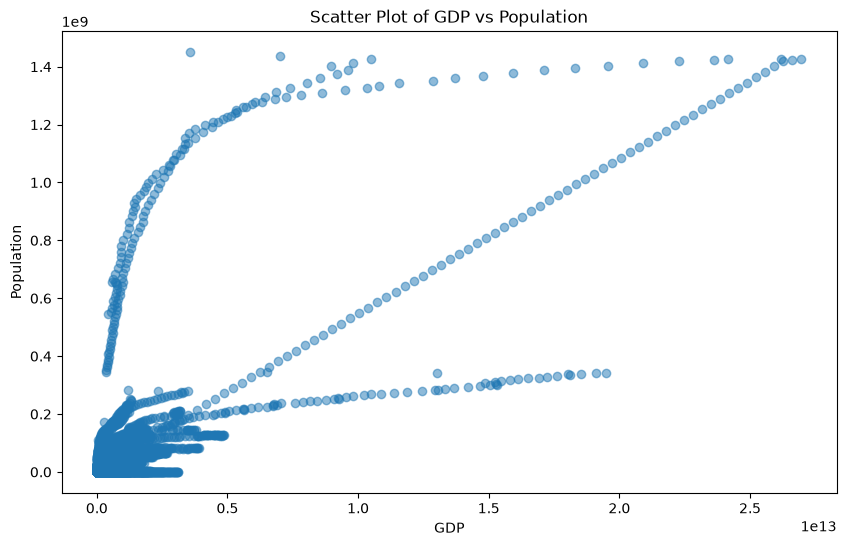

In [147]:
# plot scatter plot of gdp vs population
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['gdp'], df_cleaned['population'], alpha=0.5)
plt.title('Scatter Plot of GDP vs Population')
plt.xlabel('GDP')
plt.ylabel('Population')
plt.show()

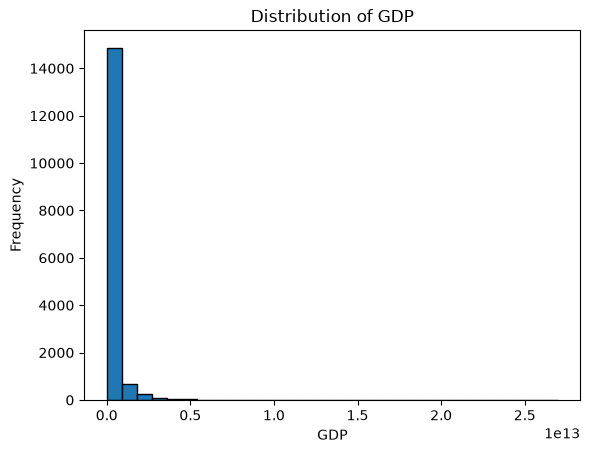

In [148]:
# plot gdp distribution
plt.hist(df_cleaned['gdp'], bins=30, edgecolor='k')
plt.title('Distribution of GDP')
plt.xlabel('GDP')
plt.ylabel('Frequency')
plt.show()